In [1044]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vrajesh0sharma7/used-car-price-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\dsapu\.cache\kagglehub\datasets\vrajesh0sharma7\used-car-price-prediction\versions\1


## Import

In [1045]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, PolynomialFeatures
from sklearn.compose import ColumnTransformer

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torch.optim as optim

import pytorch_lightning as pl
from pytorch_lightning import LightningModule
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger

from torchmetrics.regression import R2Score, MeanSquaredError, MeanAbsoluteError
from torchmetrics.functional import r2_score, mean_squared_error, mean_absolute_error

import pytorch_optimizer as optim1
import optuna
pd.set_option('display.max_columns', 100)
pl.seed_everything(42)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

Seed set to 42


## EDA

In [1046]:
df = pd.read_csv('Used_Car_Price_Prediction.csv')
df

,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,assured_buy,registered_city,registered_state,is_hot,rto,source,make,model,car_availability,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,maruti swift,2015,petrol,8063,386399,noida,18715,hatchback,manual,lxi opt,True,delhi,delhi,True,dl6c,inperson_sale,maruti,swift,in_stock,2,397677,404177.0,great,2021-04-04T07:09:18.583,True,8975,57960,False,False
1,maruti alto 800,2016,petrol,23104,265499,noida,2676,hatchback,manual,lxi,True,noida,uttar pradesh,True,up16,inperson_sale,maruti,alto 800,in_stock,1,272935,354313.0,great,2021-03-22T14:07:32.833,True,6167,39825,False,False
2,hyundai grand i10,2017,petrol,23402,477699,noida,609,hatchback,manual,sports 1.2 vtvt,True,agra,uttar pradesh,True,up80,inperson_sale,hyundai,grand i10,in_stock,1,469605,NaN,great,2021-03-20T05:36:31.311,True,11096,71655,False,False
3,maruti swift,2013,diesel,39124,307999,noida,6511,hatchback,manual,vdi,True,delhi,delhi,True,dl1c,inperson_sale,maruti,swift,in_stock,1,294262,374326.0,great,2021-01-21T12:59:19.299,True,7154,46200,False,False
4,hyundai grand i10,2015,petrol,22116,361499,noida,3225,hatchback,manual,magna 1.2 vtvt,False,new delhi,delhi,True,dl12,inperson_sale,hyundai,grand i10,in_stock,1,360716,367216.0,great,2021-04-01T13:33:40.733,True,8397,54225,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7395,honda amaze,2018,diesel,53486,604299,ghaziabad,2756,sedan,NaN,1.5 v cvt i-dtec,True,ghaziabad,uttar pradesh,True,up14,inperson_sale,honda,amaze,in_stock,1,630810,787750.0,great,2021-02-07T08:05:30.443,True,14036,90645,True,False
7396,maruti ignis,2018,petrol,8854,562599,chennai,640,hatchback,manual,delta 1.2 k12,True,chennai,tamil nadu,True,tn07,inperson_sale,maruti,ignis,in_stock,1,549440,NaN,great,2021-03-31T10:21:56.289,True,13068,84390,False,False
7397,honda amaze,2015,petrol,46300,400499,pune,795,sedan,manual,1.2 smt i vtec,True,pune,maharashtra,True,mh12,inperson_sale,honda,amaze,in_stock,1,383419,NaN,great,2021-03-04T12:40:38.652,True,9303,60075,True,False
7398,maruti alto k10,2016,petrol,27245,284099,new delhi,1155,hatchback,manual,lxi,True,delhi,delhi,True,dl8c,inperson_sale,maruti,alto k10,in_stock,1,286515,369885.0,great,2021-03-16T13:31:39.766,True,6599,42615,False,False


In [1047]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7400 entries, 0 to 7399
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             7400 non-null   object 
 1   yr_mfr               7400 non-null   int64  
 2   fuel_type            7400 non-null   object 
 3   kms_run              7400 non-null   int64  
 4   sale_price           7400 non-null   int64  
 5   city                 7400 non-null   object 
 6   times_viewed         7400 non-null   int64  
 7   body_type            7297 non-null   object 
 8   transmission         6844 non-null   object 
 9   variant              7400 non-null   object 
 10  assured_buy          7400 non-null   bool   
 11  registered_city      7390 non-null   object 
 12  registered_state     7390 non-null   object 
 13  is_hot               7400 non-null   bool   
 14  rto                  7400 non-null   object 
 15  source               7274 non-null   o

In [1048]:
df.drop(columns=['original_price', 'ad_created_on'], axis=0, inplace=True)
df.isnull().sum()

car_name                 0
yr_mfr                   0
fuel_type                0
kms_run                  0
sale_price               0
city                     0
times_viewed             0
body_type              103
transmission           556
variant                  0
assured_buy              0
registered_city         10
registered_state        10
is_hot                   0
rto                      0
source                 126
make                     0
model                    0
car_availability       620
total_owners             0
broker_quote             0
car_rating               9
fitness_certificate      8
emi_starts_from          0
booking_down_pymnt       0
reserved                 0
warranty_avail           0
dtype: int64

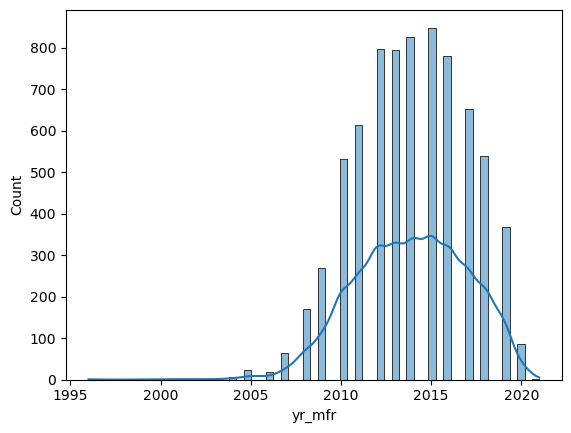

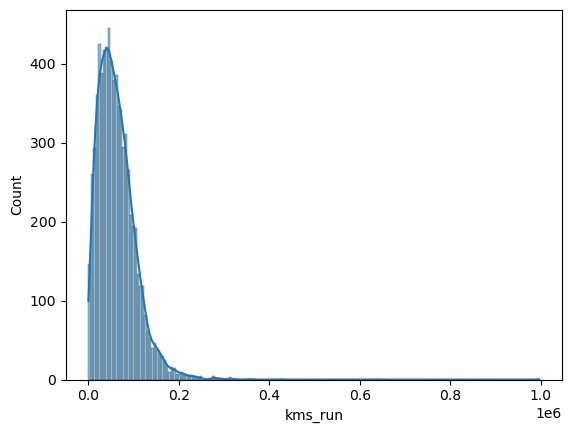

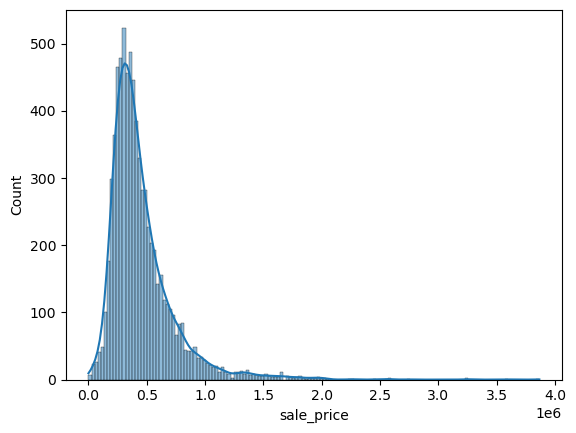

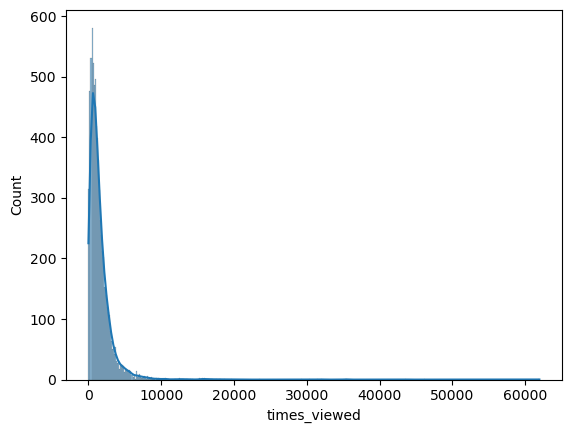

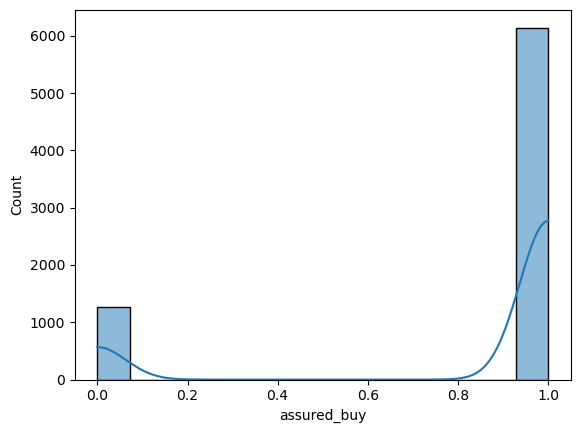

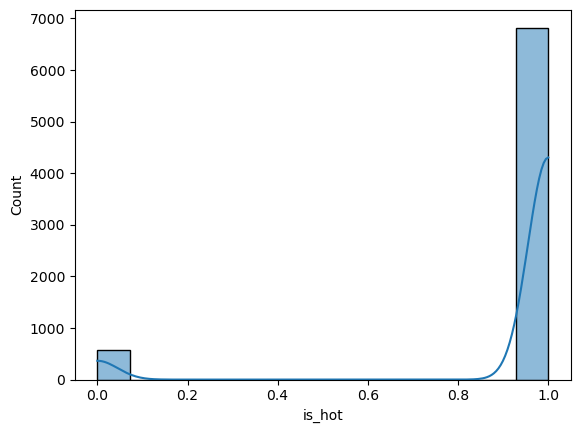

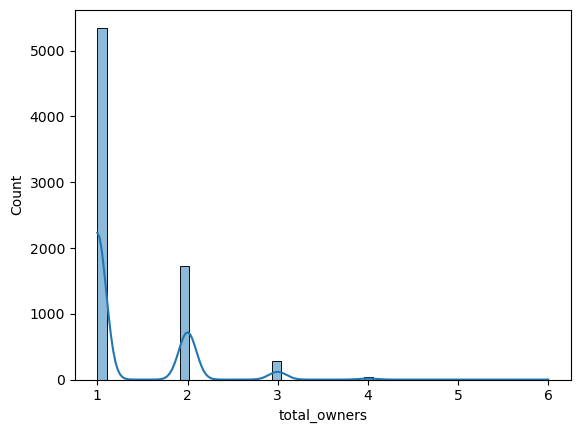

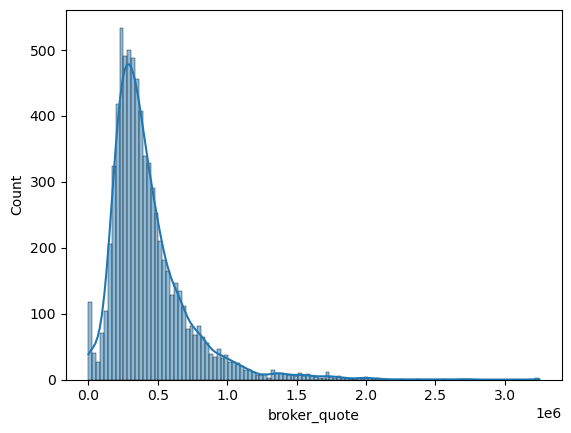

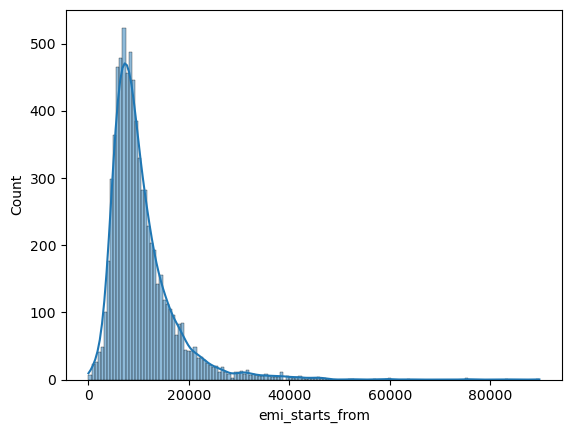

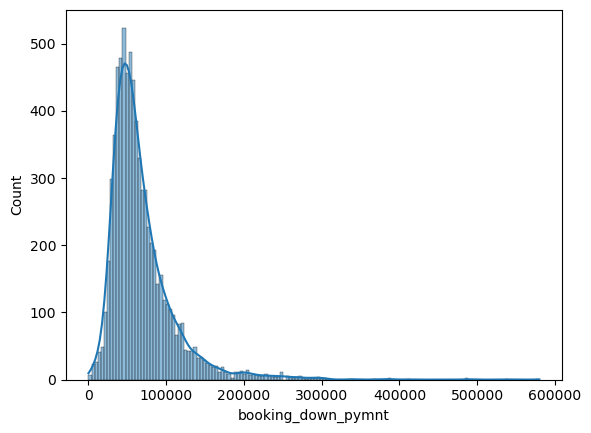

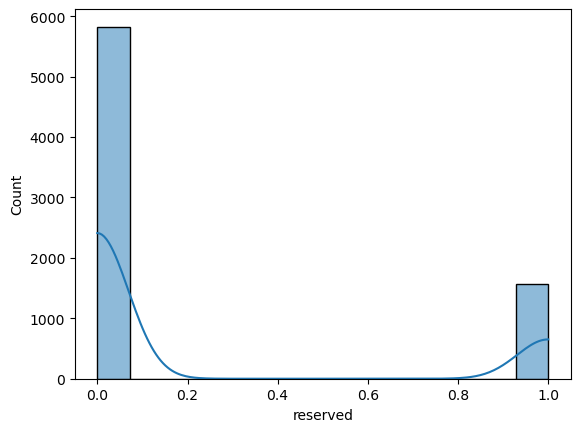

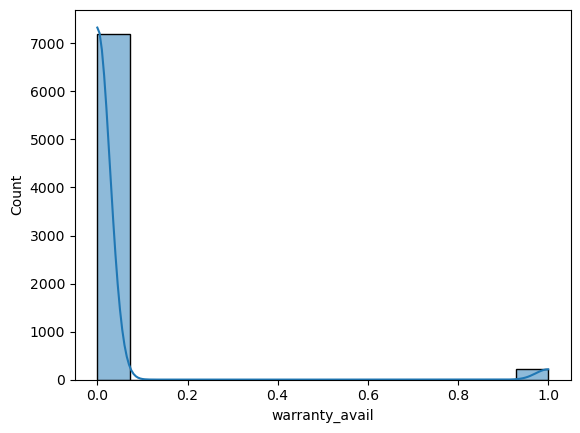

In [1049]:
for i in df.select_dtypes(exclude='object'):
    sns.histplot(df[i], kde=True)
    plt.show()

In [1050]:
for i in df.select_dtypes(exclude='object'):
    print(i)

"""warranty_avail,
reserved
is_hot
assured_buy
    """

df.warranty_avail = df.warranty_avail.astype(dtype='str')
df.reserved = df.reserved.astype(dtype='str')
df.is_hot = df.is_hot.astype(dtype='str')
df.assured_buy = df.assured_buy.astype(dtype='str')


yr_mfr
kms_run
sale_price
times_viewed
assured_buy
is_hot
total_owners
broker_quote
emi_starts_from
booking_down_pymnt
reserved
warranty_avail


In [1051]:
for i in df.select_dtypes(include='object'):
    print(f'{i}: {df[i].nunique()}')

car_name: 185
fuel_type: 5
city: 13
body_type: 5
transmission: 2
variant: 943
assured_buy: 2
registered_city: 243
registered_state: 16
is_hot: 2
rto: 261
source: 3
make: 27
model: 185
car_availability: 4
car_rating: 4
fitness_certificate: 2
reserved: 2
warranty_avail: 2


## handling missing value

In [1052]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7400 entries, 0 to 7399
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   car_name             7400 non-null   object
 1   yr_mfr               7400 non-null   int64 
 2   fuel_type            7400 non-null   object
 3   kms_run              7400 non-null   int64 
 4   sale_price           7400 non-null   int64 
 5   city                 7400 non-null   object
 6   times_viewed         7400 non-null   int64 
 7   body_type            7297 non-null   object
 8   transmission         6844 non-null   object
 9   variant              7400 non-null   object
 10  assured_buy          7400 non-null   object
 11  registered_city      7390 non-null   object
 12  registered_state     7390 non-null   object
 13  is_hot               7400 non-null   object
 14  rto                  7400 non-null   object
 15  source               7274 non-null   object
 16  make  

### Train test split

In [1053]:
X_num = df.select_dtypes(exclude='object')
X_cat = df.select_dtypes(include='object')
X_num = X_num.drop(columns='sale_price', axis=1)
y = df.sale_price

X_num_train, X_num_test, X_cat_train, X_cat_test, y_train, y_test = train_test_split(X_num, X_cat, y, random_state=42, test_size=0.2)

In [1054]:
"""
body_type              103
transmission           556
registered_city         10
registered_state        10
source                 126
car_availability       620
car_rating               9
ad_created_on            1
fitness_certificate      8
"""

'\nbody_type              103\ntransmission           556\nregistered_city         10\nregistered_state        10\nsource                 126\ncar_availability       620\ncar_rating               9\nad_created_on            1\nfitness_certificate      8\n'

In [1055]:
num = X_num.select_dtypes(include=np.number).columns.to_list()
cat = X_cat.select_dtypes(exclude=np.number).columns.to_list()
num, cat

(['yr_mfr',
  'kms_run',
  'times_viewed',
  'total_owners',
  'broker_quote',
  'emi_starts_from',
  'booking_down_pymnt'],
 ['car_name',
  'fuel_type',
  'city',
  'body_type',
  'transmission',
  'variant',
  'assured_buy',
  'registered_city',
  'registered_state',
  'is_hot',
  'rto',
  'source',
  'make',
  'model',
  'car_availability',
  'car_rating',
  'fitness_certificate',
  'reserved',
  'warranty_avail'])

In [1056]:
num_imputer = KNNImputer()
cat_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')
target_scaler = StandardScaler()

y_train = target_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test = target_scaler.transform(y_test.values.reshape(-1,1))
X_num_train_ = num_imputer.fit_transform(X_num_train)
X_num_test_ = num_imputer.transform(X_num_test)

X_num_train = pd.DataFrame(data=X_num_train_, columns=X_num_train.columns, index=X_num_train.index)
X_num_test = pd.DataFrame(data=X_num_test_, columns=X_num_test.columns, index=X_num_test.index)


In [1057]:
for i in df.select_dtypes(include='object'):
    display(df[i].value_counts())

car_name
maruti swift              535
hyundai i10               386
maruti swift dzire        377
maruti wagon r 1.0        344
hyundai grand i10         275
                         ... 
mahindra reva               1
mahindra verito             1
mahindra nuvosport          1
mercedes benz ml class      1
mercedes benz b class       1
Name: count, Length: 185, dtype: int64

fuel_type
petrol          4659
diesel          2269
petrol & cng     425
petrol & lpg      41
electric           6
Name: count, dtype: int64

city
mumbai       1336
bengaluru    1250
new delhi    1153
pune          772
chennai       702
hyderabad     633
ahmedabad     420
gurgaon       351
noida         313
ghaziabad     230
faridabad     116
lucknow       100
kolkata        24
Name: count, dtype: int64

body_type
hatchback       4358
sedan           1483
suv             1104
luxury suv       189
luxury sedan     163
Name: count, dtype: int64

transmission
manual       6215
automatic     629
Name: count, dtype: int64

...

car_availability
in_stock          6485
in_transit         225
pickup_pending      45
out_of_stock        25
Name: count, dtype: int64

car_rating
great         6299
good           881
fair           131
overpriced      80
Name: count, dtype: int64

fitness_certificate
True     7247
False     145
Name: count, dtype: int64

reserved
False    5827
True     1573
Name: count, dtype: int64

warranty_avail
False    7190
True      210
Name: count, dtype: int64

## Prepraring for embedding

In [1058]:
mapping = {}
embedding_sizes = []

for col in cat:
    X_cat_train[col] = X_cat_train[col].fillna('Unknown')
    X_cat_test[col] = X_cat_test[col].fillna('Unknown')

    unique_vals = X_cat_train[col].unique()
    col_map = {cat: i for i, cat in enumerate(unique_vals)}
    
    unknown_index = len(col_map)
    mapping[col] = col_map

    X_cat_train[col] = X_cat_train[col].map(col_map)
    X_cat_test[col] = X_cat_test[col].map(col_map)

    X_cat_test[col] = X_cat_test[col].fillna(unknown_index) 

    vocab_size = len(unique_vals) + 1 
    embedding_sizes.append((vocab_size, min(500, (vocab_size + 1) // 2)))

X_cat_train = X_cat_train.astype(int)
X_cat_test = X_cat_test.astype(int)

print("Ukuran embedding yang dihitung:")
print(embedding_sizes)
print("\nContoh X_cat_test setelah di-preprocess:")
print(X_cat_test.head())
print(f"\nNilai minimum di X_cat_test: {X_cat_test.values.min()}") # Seharusnya tidak lagi -1

Ukuran embedding yang dihitung:
[(181, 91), (6, 3), (14, 7), (7, 4), (4, 2), (860, 430), (3, 2), (212, 106), (18, 9), (3, 2), (244, 122), (5, 3), (28, 14), (181, 91), (6, 3), (6, 3), (4, 2), (3, 2), (3, 2)]

Contoh X_cat_test setelah di-preprocess:
      car_name  fuel_type  city  body_type  transmission  variant  \
4698       105          1    10          0             0        1   
5058        28          1     4          0             0      135   
7318       124          1     1          0             0      561   
169         32          1     0          1             2      859   
1952         0          0     3          0             0        0   

      assured_buy  registered_city  registered_state  is_hot  rto  source  \
4698            0               18                 7       0   25       0   
5058            0               21                 4       0   24       0   
7318            0               20                 1       0   50       0   
169             0           

In [1059]:
for i, j in mapping.items():
    if i in ['transmission', 'body_type', 'registered_city', 'registered_state', 'source', 'car_availability', 'car_rating', 'ad_created_on', 'fitness_certificate']:
        print(f'{i}: {j}')

body_type: {'hatchback': 0, 'sedan': 1, 'suv': 2, 'luxury sedan': 3, 'luxury suv': 4, 'Unknown': 5}
transmission: {'manual': 0, 'automatic': 1, 'Unknown': 2}
registered_city: {'faridabad': 0, 'dharward': 1, 'kalyan': 2, 'navi mumbai': 3, 'bangalore k r puram': 4, 'new delhi': 5, 'thane': 6, 'chennai': 7, 'pune': 8, 'delhi': 9, 'mumbai': 10, 'ahmedabad': 11, 'panvel': 12, 'mumbai west': 13, 'gandhi nagar': 14, 'bangalore central': 15, 'lucknow': 16, 'gurgaon': 17, 'hyderabad': 18, 'gandhinagar': 19, 'bengaluru': 20, 'chennai south': 21, 'banglore-cafe dly': 22, 'ghaziabad': 23, 'mahendragarh': 24, 'thanjavur': 25, 'navsari': 26, 'electronic city': 27, 'badlapur': 28, 'surat': 29, 'noida': 30, 'delhi west': 31, 'hardoi': 32, 'vijayawada': 33, 'pen': 34, 'mumbai east': 35, 'gulbarga': 36, 'dombivali': 37, 'kanpur': 38, 'jalandhar': 39, 'ahmedabad east': 40, 'ratnagiri': 41, 'salem': 42, 'bangalore south': 43, 'sanpada': 44, 'vasai': 45, 'devanahalli': 46, 'navimumbai': 47, 'satara': 48, '

### feature transform

In [1060]:
num_pipe = Pipeline([
    ('knnImput', KNNImputer()),
    ('power', PowerTransformer()),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('knnImput', KNNImputer()),
])
preprocessor1 = ColumnTransformer([
    ('num', num_pipe, num),
])
X_num_train = preprocessor1.fit_transform(X_num_train)
X_num_test = preprocessor1.transform(X_num_test)


## Neural-Network

In [1061]:
def conv_block(in_feature, out_feature, padding=1, stride=1,
             activation="relu", pool =True, maxpool=True, kernel_size=3,
             kernel_size_pool=2, pool_stride=2)-> list[nn.Sequential]:
    layers = [nn.Conv2d(in_feature, out_feature, kernel_size=kernel_size, padding=padding, stride=stride)]
    if activation == "relu":
        layers.append(nn.ReLU())
    elif activation == "leakyrelu":
        layers.append(nn.LeakyReLU())
    elif activation == "sigmoid":
        layers.append(nn.Sigmoid())
    elif activation == "tanh":
        layers.append(nn.Tanh())
    if pool:
        if maxpool:
            layers.append(nn.MaxPool2d(kernel_size=kernel_size_pool, stride=pool_stride))
        else:
            layers.append(nn.AvgPool2d(kernel_size=kernel_size_pool, stride=pool_stride))
    else:
        layers.append(nn.Identity())
    return nn.Sequential(*layers)


def linear_block(in_features, out_features, activation=None, dropout=0.0, batch_norm=None):
    layers = [nn.Linear(in_features, out_features)]
    if batch_norm:
        layers.append(nn.BatchNorm1d(out_features))
    if activation == 'relu':
        layers.append(nn.ReLU())
    elif activation == 'sigmoid':
        layers.append(nn.Sigmoid())
    elif activation == 'tanh':
        layers.append(nn.Tanh())
    elif activation == 'leakyrelu':
        layers.append(nn.LeakyReLU())
    elif activation == 'mish': layers.append(nn.Mish())
    elif activation == 'softmax':
        layers.append(nn.Softmax(dim=1))
    elif activation == 'elu':
        layers.append(nn.ELU())
    elif activation == 'selu':
        layers.append(nn.SELU())
    elif activation == 'lsoftmax':
        layers.append(nn.LogSoftmax(dim=1))
    if dropout > 0.0:
        layers.append(nn.Dropout(dropout))
    return nn.Sequential(*layers)

In [1062]:
class CharbonnierLoss(nn.Module):
    def __init__(self, epsilon=1e-3):
        super().__init__()
        self.epsilon_sq = epsilon**2

    def forward(self, y_pred, y_true):
        error = y_pred - y_true
        return torch.mean(torch.sqrt(error**2 + self.epsilon_sq))
    
class LogCoshLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        error = y_pred - y_true
        return torch.mean(torch.log(torch.cosh(error)))


In [1063]:
from typing import Any
from pytorch_optimizer import SophiaH

class EmbbedDataset(Dataset):
    def __init__(self, X_cat, X_num, y) -> None:
        super().__init__()
        self.categorical = torch.tensor(X_cat, dtype=torch.long)
        self.numeric = torch.tensor(X_num, dtype=torch.float32)
        self.labels = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.categorical[idx], self.numeric[idx], self.labels[idx]
    
class ANN(LightningModule):
    def __init__(self, embedding_sizes, num_numerical) -> None:
        super().__init__()
        self.embedding = nn.ModuleList([nn.Embedding(vocab_size, dim) for vocab_size, dim in embedding_sizes])
        num_embedding_dim = sum(dim for _, dim in embedding_sizes)
        self.fc = nn.Sequential(
            linear_block(num_embedding_dim+ num_numerical, 32, activation='mish', batch_norm=True, dropout=0),
            linear_block(32, 16, activation='mish', batch_norm=True, dropout=0),
            linear_block(16, 4, activation='mish', batch_norm=True, dropout=0),
            # linear_block(4, 4, activation='mish', batch_norm=True),
            linear_block(4, 1, activation=None, batch_norm=None)
        )
    def forward(self, X_cat, X_num):
        embedd_feature = [emb(X_cat[:, i]) for i, emb in enumerate(self.embedding)]
        total_embedd = torch.cat(embedd_feature, dim=1)
        combine_feature = torch.cat([total_embedd, X_num], dim=1)
        return self.fc(combine_feature)
    
class PL(LightningModule):
    def __init__(self, model, learning_rate) -> None:
        super().__init__()
        self.model = model
        self.learning_rate = learning_rate
        self.criterion = LogCoshLoss()
        self.r2 = R2Score()
    
    def forward(self, X_cat, X_num) -> Any:
        return self.model(X_cat, X_num)

    def training_step(self, batch, batch_idx):
        X_cat, X_num, labels = batch
        # labels = labels.unsqueeze(1)
        outputs = self(X_cat, X_num)
        loss = self.criterion(outputs, labels)
        r2 = self.r2(outputs, labels)
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        self.log('train_r2', r2, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def validation_step(self, batch, batch_idx):
        X_cat, X_num, labels = batch
        # labels = labels.unsqueeze(1)
        outputs = self(X_cat, X_num)
        loss = self.criterion(outputs, labels)
        r2 = self.r2(outputs, labels)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True, logger=True)
        self.log('val_r2', r2, on_epoch=True, prog_bar=True, logger=True)

    def test_step(self, batch, batch_idx):
        X_cat, X_num, labels = batch
        # labels = labels.unsqueeze(1)
        outputs = self(X_cat, X_num)
        loss = self.criterion(outputs, labels)
        r2 = self.r2(outputs, labels)
        self.log('test_loss', loss, on_epoch=True, prog_bar=True, logger=True)
        self.log('test_r2', r2, on_epoch=True, prog_bar=True, logger=True)

    def backward(self, loss, *args, **kwargs):
        loss.backward(create_graph=True)

    def configure_optimizers(self):
        optimizer = optim1.Lion(self.parameters(), lr=self.learning_rate)
        return optimizer

    def predict_step(self, batch, batch_idx, dataloader_idx=None):
        X_cat, X_num, _ = batch
        return self(X_cat, X_num)

In [1064]:
if torch.cuda.is_available():
    accelerator_type = 'gpu'
    devices_to_use = 1
else:
    accelerator_type = 'cpu'
    devices_to_use = 'auto'

checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    dirpath='checkpoints_regression/',
    filename='UsedCar-{epoch:02d}-{val_loss:.4f}',
    save_top_k=1,
    mode='min'
)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    mode='min',
)
lr_monitor_callback = LearningRateMonitor(logging_interval='epoch')

trainer1 = pl.Trainer(
    max_epochs=300,
    callbacks=[checkpoint_callback, early_stopping, lr_monitor_callback],
    logger=TensorBoardLogger("tb_logs_reg", name="simple_model_experiment"),
    accelerator=accelerator_type,
    devices=devices_to_use,
    log_every_n_steps=10,
    deterministic=True,
    
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


## Embedding dataset

In [1065]:
bs = 128
trainset = EmbbedDataset(X_cat_train.values, X_num_train, y_train)
trainloader = DataLoader(trainset, batch_size=bs, shuffle=True)

testset = EmbbedDataset(X_cat_test.values, X_num_test, y_test)
testloader = DataLoader(testset, batch_size=bs, shuffle=False)

In [1066]:
feature, feature1, target = next(iter(testloader))
feature.shape, feature1.shape, target.shape

(torch.Size([128, 19]), torch.Size([128, 7]), torch.Size([128, 1]))

In [1067]:
model = PL(ANN(embedding_sizes, feature1.shape[1]), learning_rate=5e-4)

In [1068]:
trainer1.fit(model, trainloader, testloader)


  | Name      | Type        | Params | Mode 
--------------------------------------------------
0 | model     | ANN         | 485 K  | train
1 | criterion | LogCoshLoss | 0      | train
2 | r2        | R2Score     | 0      | train
--------------------------------------------------
485 K     Trainable params
0         Non-trainable params
485 K     Total params
1.942     Total estimated model params size (MB)
38        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [1069]:
trainer1.validate(model, testloader, ckpt_path='best')

Restoring states from the checkpoint path at C:\Users\dsapu\Project\Python\repo\dlp\UsedCar\checkpoints_regression\UsedCar-epoch=137-val_loss=0.0055.ckpt
Loaded model weights from the checkpoint at C:\Users\dsapu\Project\Python\repo\dlp\UsedCar\checkpoints_regression\UsedCar-epoch=137-val_loss=0.0055.ckpt


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         val_loss          │   0.005493530537933111    │
│          val_r2           │    0.9857091903686523     │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.005493530537933111, 'val_r2': 0.9857091903686523}]